# 04. Случайный лес (Random Forest)

В этом ноутбуке:
- загрузка обработанных данных
- обучение базовой модели случайного леса с `class_weight='balanced'`
- подбор гиперпараметров с помощью RandomizedSearchCV
- оценка качества на валидационной выборке
- подбор порога классификации по F1-мере
- построение матрицы ошибок и ROC-кривой
- сохранение модели, метрик и графиков

### 1. Загрузка данных

In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
import os

# Создаём папку для графиков этой модели
FIGURES_DIR = '../reports/figures/04_random_forest'
os.makedirs(FIGURES_DIR, exist_ok=True)

# Загрузка обработанных данных
X_train = np.load('../data/processed/X_train_scaled.npy')
X_val = np.load('../data/processed/X_val_scaled.npy')
y_train = np.load('../data/processed/y_train.npy')
y_val = np.load('../data/processed/y_val.npy')

print(f"Размер обучающей выборки: {X_train.shape[0]} строк")
print(f"Размер валидационной выборки: {X_val.shape[0]} строк")
print(f"Доля дефолтов в обучающей выборке: {y_train.mean():.4f}")
print(f"Доля дефолтов в валидационной выборке: {y_val.mean():.4f}")

Размер обучающей выборки: 119773 строк
Размер валидационной выборки: 29944 строк
Доля дефолтов в обучающей выборке: 0.0660
Доля дефолтов в валидационной выборке: 0.0660


### 2. Обучение базовой модели случайного леса

In [2]:
# Базовая модель с балансировкой классов
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
rf_base.fit(X_train, y_train)
print("Базовая модель случайного леса обучена")

Базовая модель случайного леса обучена


### 3. Оценка качества базовой модели

Precision: 0.5423
Recall:    0.1361
F1-score:  0.2176
ROC-AUC:   0.8290


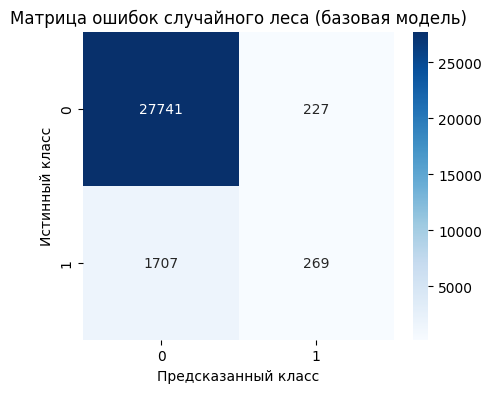

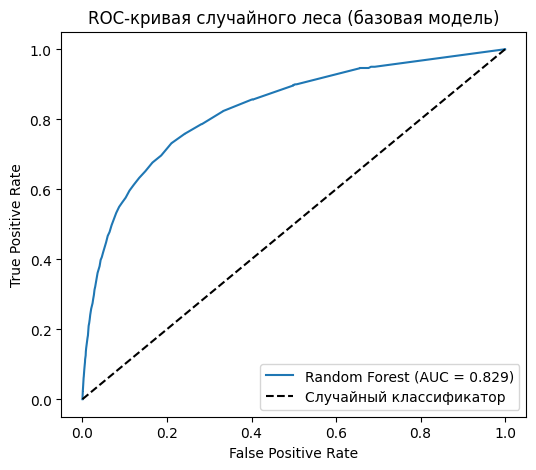

In [10]:
y_pred = rf_base.predict(X_val)
y_pred_proba = rf_base.predict_proba(X_val)[:, 1]

precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_pred_proba)

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

# Матрица ошибок
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок случайного леса (базовая модель)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.savefig(os.path.join(FIGURES_DIR, 'rf_confusion_matrix_base.png'), bbox_inches='tight')
plt.show()

# ROC-кривая
fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc_val:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая случайного леса (базовая модель)')
plt.legend()
plt.savefig(os.path.join(FIGURES_DIR, 'rf_roc_curve_base.png'), bbox_inches='tight')
plt.show()

### 4. Подбор гиперпараметров (RandomizedSearchCV)

Для ускорения используем случайный поиск по сетке параметров.

In [4]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_tune = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    rf_tune, param_dist, n_iter=20, cv=3, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)
random_search.fit(X_train, y_train)

print(f"Лучшие параметры: {random_search.best_params_}")
print(f"Лучший ROC-AUC на кросс-валидации: {random_search.best_score_:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Лучшие параметры: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}
Лучший ROC-AUC на кросс-валидации: 0.8574


In [12]:
# 4. Подбор гиперпараметров (улучшенный: n_iter=50, cv=5)
import time

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf_tune = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)

random_search_improved = RandomizedSearchCV(
    rf_tune, param_dist, n_iter=50, cv=5, scoring='roc_auc',
    random_state=42, n_jobs=-1, verbose=1
)

start_time = time.time()
random_search_improved.fit(X_train, y_train)
end_time = time.time()

print(f"Время выполнения: {end_time - start_time:.2f} секунд")
print(f"Лучшие параметры: {random_search_improved.best_params_}")
print(f"Лучший ROC-AUC на кросс-валидации: {random_search_improved.best_score_:.4f}")

# Оценка на валидационной выборке
best_rf_improved = random_search_improved.best_estimator_
y_pred_improved = best_rf_improved.predict(X_val)
y_pred_proba_improved = best_rf_improved.predict_proba(X_val)[:, 1]

precision_improved = precision_score(y_val, y_pred_improved)
recall_improved = recall_score(y_val, y_pred_improved)
f1_improved = f1_score(y_val, y_pred_improved)
roc_auc_improved = roc_auc_score(y_val, y_pred_proba_improved)

print("Метрики улучшенной модели:")
print(f"Precision: {precision_improved:.4f}")
print(f"Recall:    {recall_improved:.4f}")
print(f"F1-score:  {f1_improved:.4f}")
print(f"ROC-AUC:   {roc_auc_improved:.4f}")

# Сохранение метрик в отдельный файл
with open(os.path.join(FIGURES_DIR, 'metrics_improved.txt'), 'w', encoding='utf-8') as f:
    f.write("=== Улучшенный подбор (n_iter=50, cv=5) ===\n")
    f.write(f"Лучшие параметры: {random_search_improved.best_params_}\n")
    f.write(f"Лучший ROC-AUC на кросс-валидации: {random_search_improved.best_score_:.4f}\n")
    f.write(f"Precision: {precision_improved:.4f}\n")
    f.write(f"Recall:    {recall_improved:.4f}\n")
    f.write(f"F1-score:  {f1_improved:.4f}\n")
    f.write(f"ROC-AUC:   {roc_auc_improved:.4f}\n")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Время выполнения: 662.47 секунд
Лучшие параметры: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}
Лучший ROC-AUC на кросс-валидации: 0.8589
Метрики улучшенной модели:
Precision: 0.2234
Recall:    0.7060
F1-score:  0.3394
ROC-AUC:   0.8579


### 5. Оценка модели с лучшими гиперпараметрами

Метрики оптимизированной модели:
Precision: 0.2234
Recall:    0.7100
F1-score:  0.3399
ROC-AUC:   0.8577


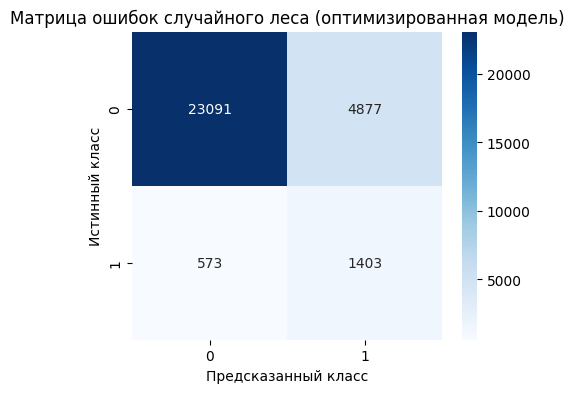

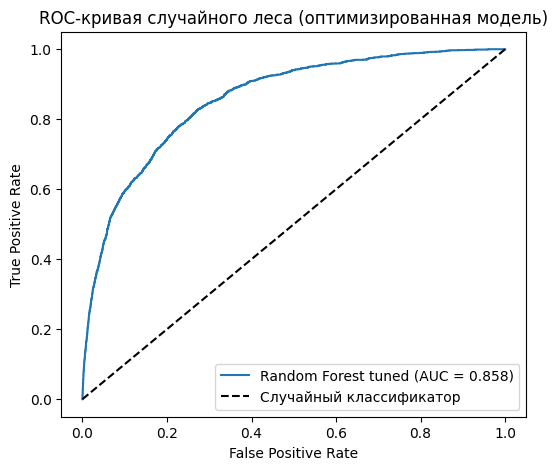

In [11]:
best_rf = random_search.best_estimator_
y_pred_best = best_rf.predict(X_val)
y_pred_proba_best = best_rf.predict_proba(X_val)[:, 1]

precision_best = precision_score(y_val, y_pred_best)
recall_best = recall_score(y_val, y_pred_best)
f1_best = f1_score(y_val, y_pred_best)
roc_auc_best = roc_auc_score(y_val, y_pred_proba_best)

print(f"Метрики оптимизированной модели:")
print(f"Precision: {precision_best:.4f}")
print(f"Recall:    {recall_best:.4f}")
print(f"F1-score:  {f1_best:.4f}")
print(f"ROC-AUC:   {roc_auc_best:.4f}")

# Матрица ошибок
cm_best = confusion_matrix(y_val, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues')
plt.title('Матрица ошибок случайного леса (оптимизированная модель)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.savefig(os.path.join(FIGURES_DIR, 'rf_confusion_matrix_tuned.png'), bbox_inches='tight')
plt.show()

# ROC-кривая
fpr_best, tpr_best, _ = roc_curve(y_val, y_pred_proba_best)
roc_auc_best_val = auc(fpr_best, tpr_best)

plt.figure(figsize=(6,5))
plt.plot(fpr_best, tpr_best, label=f'Random Forest tuned (AUC = {roc_auc_best_val:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая случайного леса (оптимизированная модель)')
plt.legend()
plt.savefig(os.path.join(FIGURES_DIR, 'rf_roc_curve_tuned.png'), bbox_inches='tight')
plt.show()

### 6. Подбор порога классификации по F1-мере (для оптимизированной модели)

Лучший порог: 0.670
F1-score при этом пороге: 0.4225
После подбора порога (best=0.670):
Precision: 0.3576
Recall:    0.5162
F1-score:  0.4225


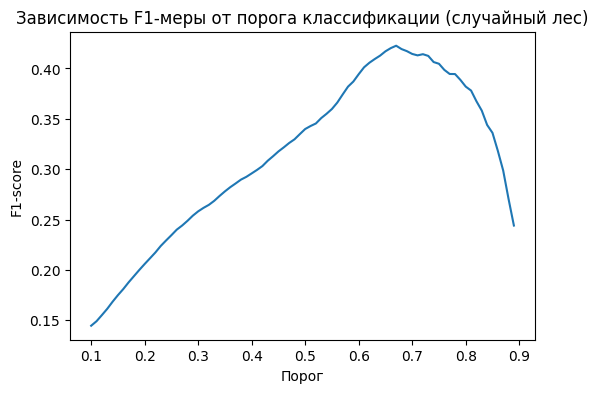

In [9]:
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_val, y_pred_proba_best >= t) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print(f"Лучший порог: {best_threshold:.3f}")
print(f"F1-score при этом пороге: {best_f1:.4f}")

# Применяем новый порог
y_pred_adj = (y_pred_proba_best >= best_threshold).astype(int)
precision_adj = precision_score(y_val, y_pred_adj)
recall_adj = recall_score(y_val, y_pred_adj)
f1_adj = f1_score(y_val, y_pred_adj)

print(f"После подбора порога (best={best_threshold:.3f}):")
print(f"Precision: {precision_adj:.4f}")
print(f"Recall:    {recall_adj:.4f}")
print(f"F1-score:  {f1_adj:.4f}")

# График зависимости F1 от порога
plt.figure(figsize=(6,4))
plt.plot(thresholds, f1_scores)
plt.xlabel('Порог')
plt.ylabel('F1-score')
plt.title('Зависимость F1-меры от порога классификации (случайный лес)')
plt.savefig(os.path.join(FIGURES_DIR, 'rf_f1_threshold.png'), bbox_inches='tight')
plt.show()

### 7. Вывод: сравнение базовой и оптимизированной моделей

In [7]:
print("Сравнение базовой и оптимизированной модели случайного леса:")
print(f"Базовая:      Precision={precision:.4f}, Recall={recall:.4f}, F1={f1:.4f}, AUC={roc_auc:.4f}")
print(f"Оптимизированная: Precision={precision_best:.4f}, Recall={recall_best:.4f}, F1={f1_best:.4f}, AUC={roc_auc_best:.4f}")

# Если улучшение есть, выбираем оптимизированную модель, иначе базовую
if roc_auc_best > roc_auc:
    rf_final = best_rf
    print("Финальная модель: оптимизированная (RandomizedSearchCV)")
else:
    rf_final = rf_base
    print("Финальная модель: базовая (улучшения нет)")

Сравнение базовой и оптимизированной модели случайного леса:
Базовая:      Precision=0.5423, Recall=0.1361, F1=0.2176, AUC=0.8290
Оптимизированная: Precision=0.2234, Recall=0.7100, F1=0.3399, AUC=0.8577
Финальная модель: оптимизированная (RandomizedSearchCV)


### 8. Сохранение модели, метрик и графиков

In [8]:
model_dir = '../models'
os.makedirs(model_dir, exist_ok=True)

# Сохраняем финальную модель
with open(os.path.join(model_dir, 'random_forest.pkl'), 'wb') as f:
    pickle.dump(rf_final, f)

# Сохраняем метрики в текстовый файл
with open(os.path.join(FIGURES_DIR, 'metrics.txt'), 'w', encoding='utf-8') as f:
    f.write("=== Базовые метрики ===\n")
    f.write(f"Precision: {precision:.4f}\n")
    f.write(f"Recall:    {recall:.4f}\n")
    f.write(f"F1-score:  {f1:.4f}\n")
    f.write(f"ROC-AUC:   {roc_auc:.4f}\n\n")
    
    f.write("=== Оптимизированная модель (RandomizedSearchCV) ===\n")
    f.write(f"Лучшие параметры: {random_search.best_params_}\n")
    f.write(f"Precision: {precision_best:.4f}\n")
    f.write(f"Recall:    {recall_best:.4f}\n")
    f.write(f"F1-score:  {f1_best:.4f}\n")
    f.write(f"ROC-AUC:   {roc_auc_best:.4f}\n\n")
    
    f.write("=== Подбор порога (по F1) ===\n")
    f.write(f"Лучший порог: {best_threshold:.3f}\n")
    f.write(f"Precision при лучшем пороге: {precision_adj:.4f}\n")
    f.write(f"Recall при лучшем пороге:    {recall_adj:.4f}\n")
    f.write(f"F1 при лучшем пороге:        {f1_adj:.4f}\n")

print("Модель и метрики сохранены")

Модель и метрики сохранены
